# PDA-3. Библиотека SciPy

# 1. Что такое библиотека SciPy?

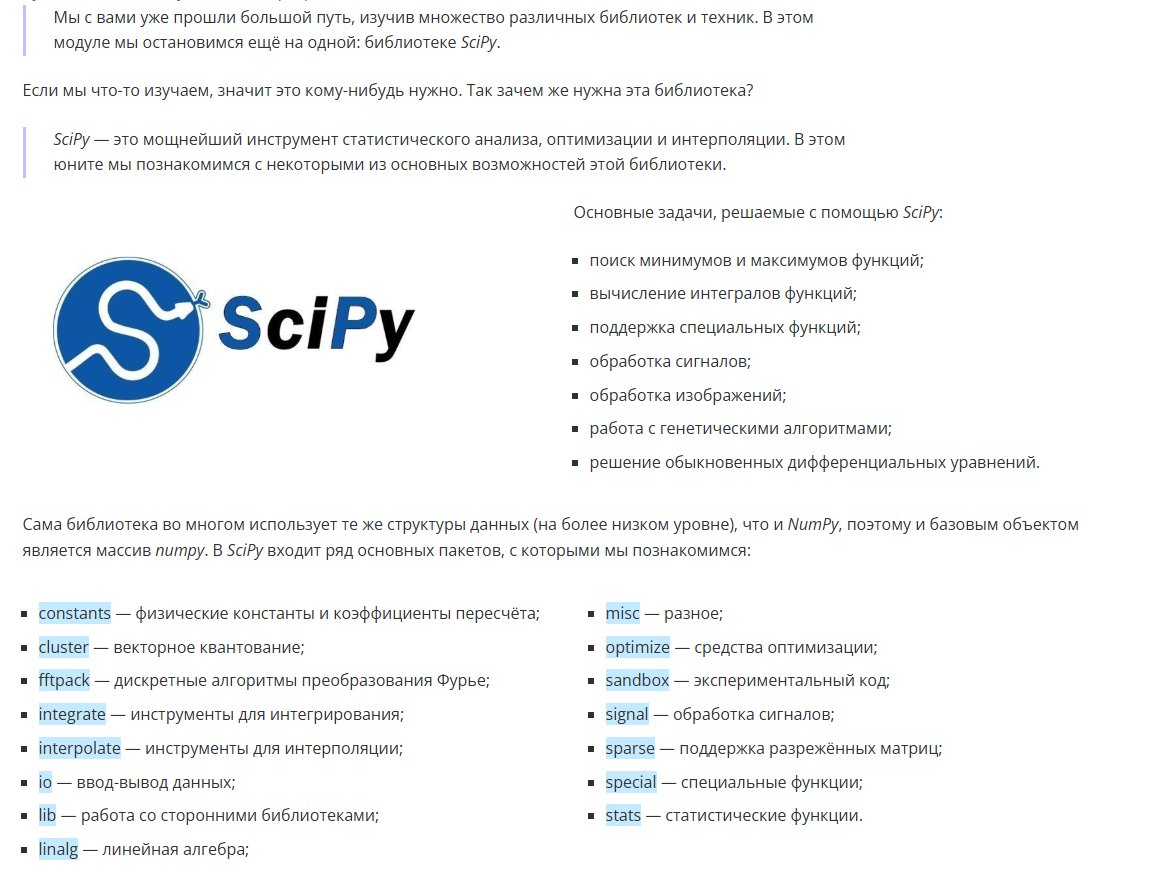

В рамках курса у нас будут как теоретические, так и небольшие практические занятия по работе со SciPy. Для практики необходимо установить саму библиотеку на локальную машину. Это можно сделать командой:

In [ ]:
# pip install scipy==1.6.2

После установки давайте проверим, что всё работает, и заодно познакомимся с одной важной спецификой библиотеки.

1. Импортируем пакет с оптимизаторами.

In [3]:
from scipy import optimize

2. Для просмотра документации импортируем numpy.

In [4]:
import numpy as np

3. Посмотрим документацию минимизатора функции (что он из себя представляет, мы разберём далее).

In [5]:
np.info(optimize.fmin)

 fmin(func, x0, args=(), xtol=0.0001, ftol=0.0001, maxiter=None, maxfun=None,
      full_output=0, disp=1, retall=0, callback=None, initial_simplex=None)

Minimize a function using the downhill simplex algorithm.

This algorithm only uses function values, not derivatives or second
derivatives.

Parameters
----------
func : callable func(x,*args)
    The objective function to be minimized.
x0 : ndarray
    Initial guess.
args : tuple, optional
    Extra arguments passed to func, i.e., ``f(x,*args)``.
xtol : float, optional
    Absolute error in xopt between iterations that is acceptable for
    convergence.
ftol : number, optional
    Absolute error in func(xopt) between iterations that is acceptable for
    convergence.
maxiter : int, optional
    Maximum number of iterations to perform.
maxfun : number, optional
    Maximum number of function evaluations to make.
full_output : bool, optional
    Set to True if fopt and warnflag outputs are desired.
disp : bool, optional
    Set to Tru

Конечно, традиционная команда help тоже сработает, но разработчики рекомендуют использовать np.info, особенно в интерактивных сессиях (в терминале), чтобы не получить сбой. 

На этом можно закончить это небольшое введение. Давайте проверим, что мы узнали!

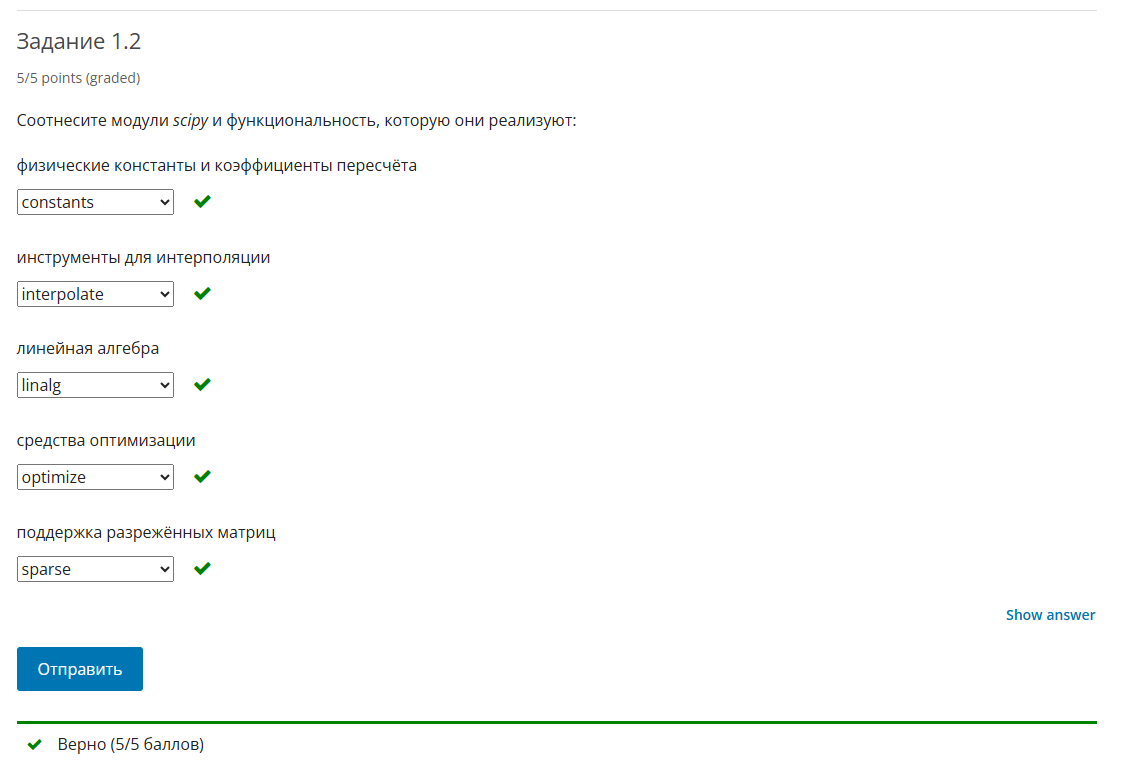

# 2. Sparse-матрицы

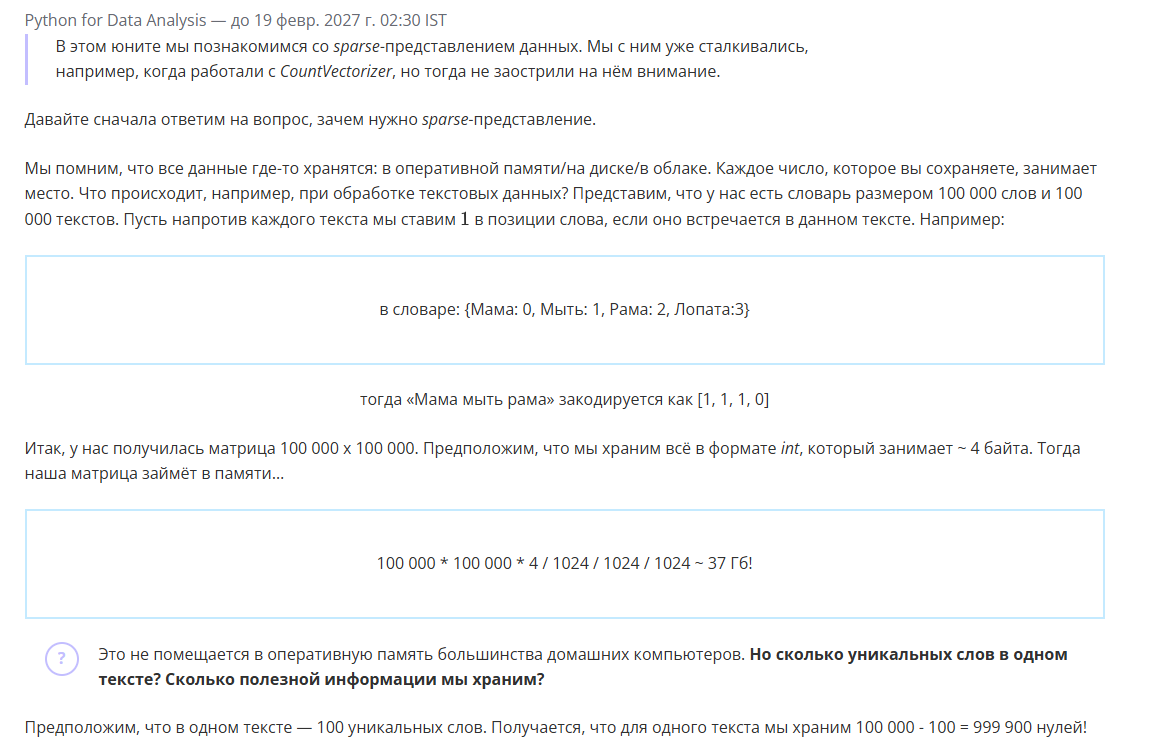

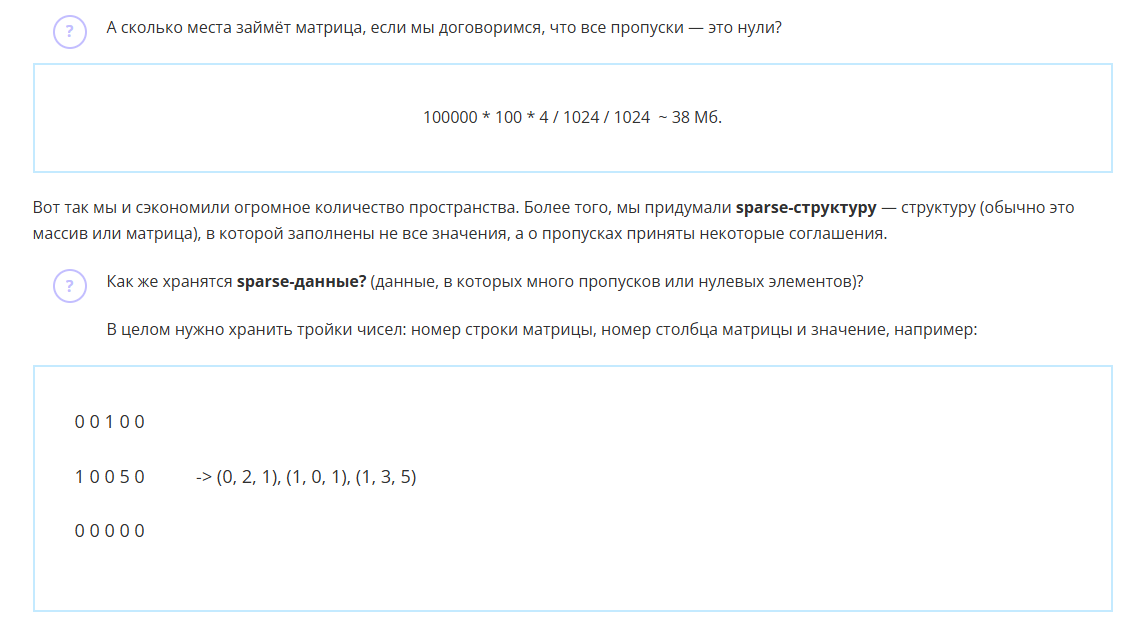

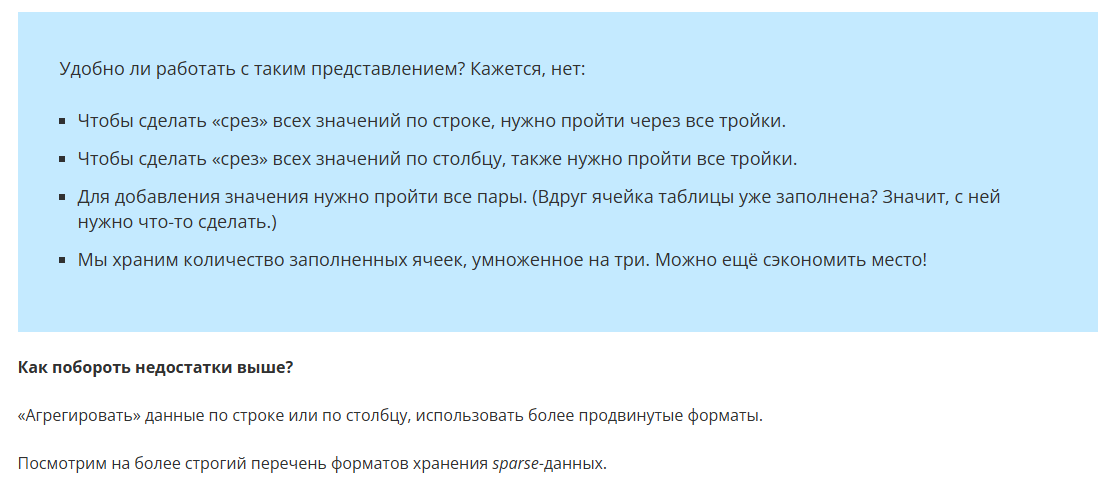

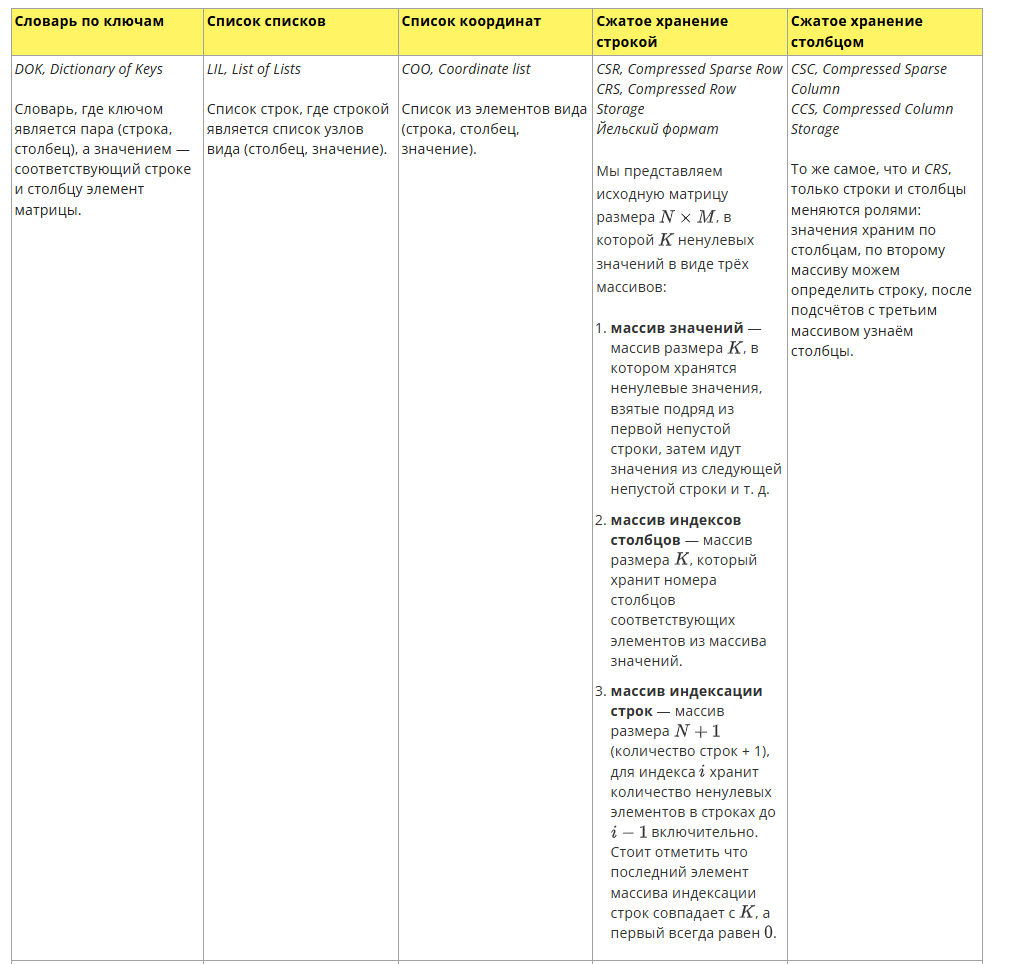

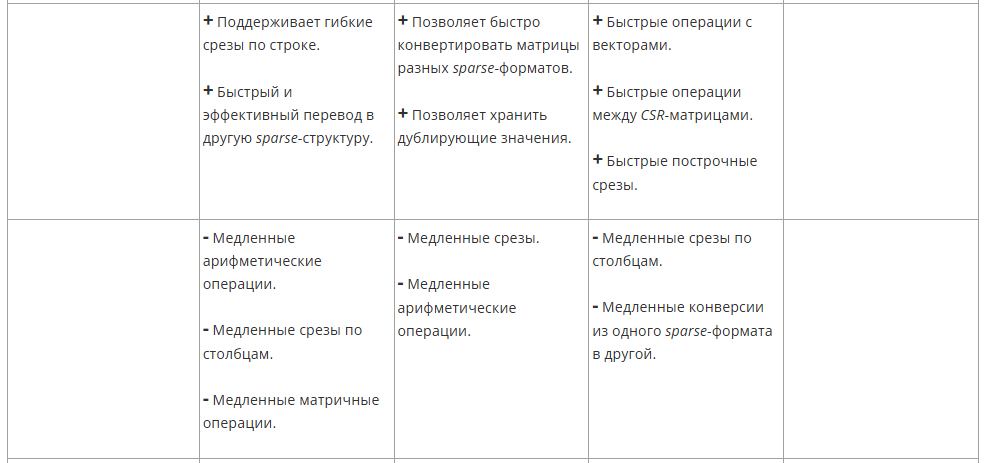

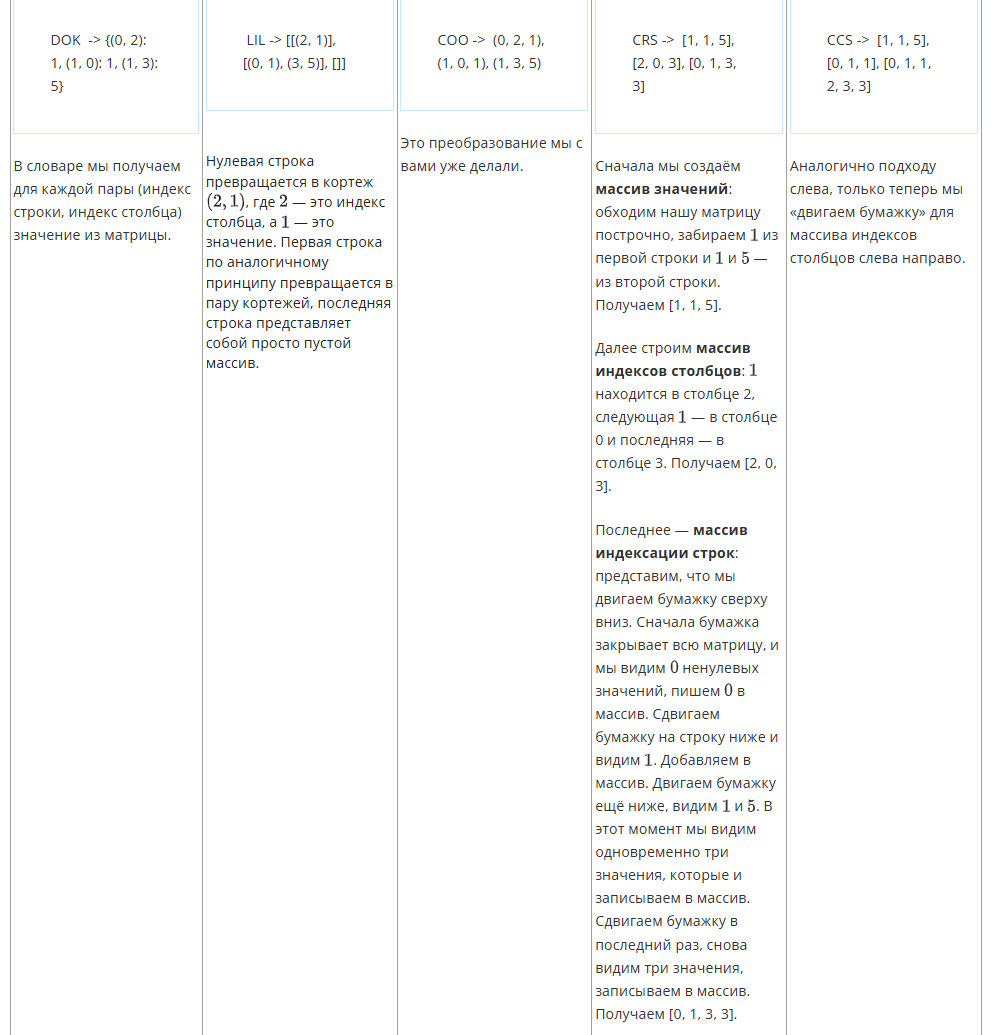

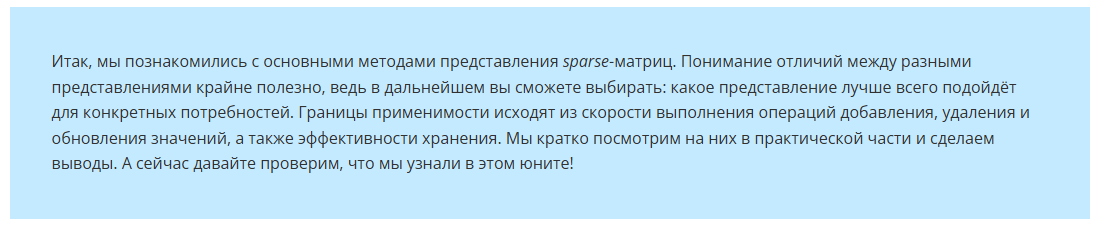

# 3. Sparse-матрицы. Практика

→ Давайте теперь посмотрим, как это работает на практике. Sparse-структуры определены в scipy в пакете sparse (как ни странно). Заглянем в него! 

Он включает следующие классы:

- bsr_matrix — block Sparse Row matrix;
- coo_matrix — a sparse matrix in COOrdinate format;
- csc_matrix — compressed sparse column matrix;
- csr_matrix — сompressed sparse row matrix;
- dia_matrix — sparse matrix with DIAgonal storage;
- dok_matrix — dictionary of keys based sparse matrix;
- lil_matrix — row-based list of lists sparse matrix.

Мы не разбирали работу bsr- и dia-хранилища. В рамках этого модуля мы не будем их рассматривать — они не сильно распространены и, скорее всего, вы с ними не столкнётесь, а полученных знаний вам хватит для освоения и других техник.

Также пакет включает в себя ряд методов для работы со sparse-матрицами, с которыми мы познакомимся далее. Давайте узнаем, как создавать матрицы разных типов.

1. Научимся создавать матрицы разных типов:

In [6]:
from scipy import sparse
import numpy as np

# CSR-матрица
sample_csr = sparse.csr_matrix([[1, 2, 0], [0, 0, 3], [4, 0, 5]])
row = np.array([0, 2, 2, 0, 1, 2])
col = np.array([0, 0, 1, 2, 2, 2])
data = np.array([1, 2, 3, 4, 5, 6])

# CSС-матрица
sample_csc = sparse.csc_matrix((data, (row, col)), shape=(3, 3))

I = np.array([0,3,1,0])
J = np.array([0,3,1,2])
V = np.array([4,5,7,9])

# COO-матрица
sample_coo = sparse.coo_matrix((V,(I,J)),shape=(4,4))
# LIL матрица
sample_lil = sparse.lil_matrix((3, 3))

# DOK-матрица
sample_dok = sparse.dok_matrix((5, 5), dtype=np.float32)

2. Итак, мы научились создавать матрицы разных видов. Давайте научимся их заполнять. К счастью, большая часть механики уже реализована за нас:

In [7]:
from numpy.random import rand

sample_lil[0, :3] = np.ones(3)
sample_lil[1, :3] = sample_lil[0, :3]
sample_lil.setdiag(rand(3))

for i in range(5):
    for j in range(5):
        sample_dok [i, j] = i + j

К сожалению, COO-, CSC-, CSR-матрицы очень плохо изменяемы после создания — большая часть операций для них не определена. Поэтому COO-матрицы будем считать неизменяемыми. Для обновления CSC и CSR используется матричное сложение или перевод в dense-формат с последующим обновлением и переводом обратно в sparse-формат. Давайте посмотрим, как это делается, на примере CSR:

In [8]:
# Переведем в dense и исправим необходимые значения
tmp_filled = sample_csr.toarray()
tmp_filled[0, 0] = 10
sample_csr_new = sparse.csr_matrix(tmp_filled)

# Аналогично через сложение двух матриц
tmp_csr = sparse.csr_matrix([[5, 0, 0], [0, 0, 0], [0, 0, 0]])
sample_csr_new = sample_csr + tmp_csr

3. С матрицами можно делать большинство матричных и матрично-векторных операций, которые мы совершали с помощью numpy. 

Одно важное уточнение: матричные операции мы можем совершать только между матрицами одного формата.

In [9]:
v = np.array([1, 0, -1])
tmp_csr = sparse.csr_matrix([[5, 0, 0], [0, 0, 0], [0, 0, 0]])
sample_csr = sample_csr + tmp_csr
sample_csr = sample_csr.dot(v)
v = np.array([1, 0, -1])
tmp_csc = sparse.csc_matrix([[5, 0, 0], [0, 0, 0], [0, 0, 0]])
sample_csc = sample_csc + tmp_csc
sample_csc = sample_csc.dot(v)

sample_lil_tmp = sparse.lil_matrix((3, 3))
sample_lil = sample_lil.dot(v) + sample_lil_tmp

Мы рассмотрели основные операции со sparse-матрицами. Важно понимать, что многое уже реализовано за нас, и мы можем просто переиспользовать наши знания по numpy. Давайте пройдём небольшую практику и потренируемся работать со sparse-матрицами.

### Задание 3.1
 
Создайте матрицу CSR размером 3x4, в которой первый столбец заполнен единицами, а третий — четвёрками. Создайте sparse CSR-матрицу с помощью трёх массивов и запишите в переменную tmp. После каждой запятой обязательно добавьте пробел.


In [10]:
data = np.array([1, 4, 1, 4, 1, 4])
indices = np.array([0, 2, 0, 2, 0, 2])
indptr = np.array([0, 2, 4, 6])

tmp = sparse.csr_matrix((data, indices, indptr), shape=(3, 4))

In [11]:
tmp = sparse.csr_matrix(([1, 4, 1, 4, 1, 4], ([0, 0, 1, 1, 2, 2], [0, 2, 0, 2, 0, 2])), shape=(3, 4))

tmp = sparse.csr_matrix(([1, 4, 1, 4, 1, 4], ([0, 0, 1, 1, 2, 2], [1, 3, 1, 3, 1, 3])), shape=(3, 4))

tmp = sparse.csr_matrix(([1, 4, 1, 4, 1, 4], [1, 3, 1, 3, 1, 3], [0, 2, 4, 6]), shape=(3, 4))

tmp = sparse.csr_matrix(([1, 4, 1, 4, 1, 4], [0, 2, 0, 2, 0, 2], [0, 2, 4, 6]), shape=(3, 4))

### Задание 3.4
 
Создайте матрицу CSR из списка списков размером , заполненную числами от  до . После каждой запятой обязательно добавьте пробел.

In [12]:
sparse.csr_matrix([[1, 2, 3], [4, 5, 6]])

sparse.csr_matrix(([1, 2, 3, 4, 5, 6], [0, 1, 2, 0, 1, 2], [0, 3, 6]))

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (2, 3)>

# 4. Матрицы расстояний

Следующим важнейшим модулем в scipy является модуль **spatial**. 

Он включает в себя две основных функциональности: 

- структуры данных для работы с симплексами и более сложными структурами;
- алгоритмы поиска расстояния между группами точек, в том числе быстрый поиск ближайших соседей.

Но обо всём по порядку!

Начнём с более сложных структур данных (рассмотрим только некоторые из них):

**Триангуляция Делоне** — триангуляция для заданного множества точек S на плоскости, при которой для любого треугольника все точки из S за исключением точек, являющихся его вершинами, лежат вне окружности, описанной вокруг треугольника. 

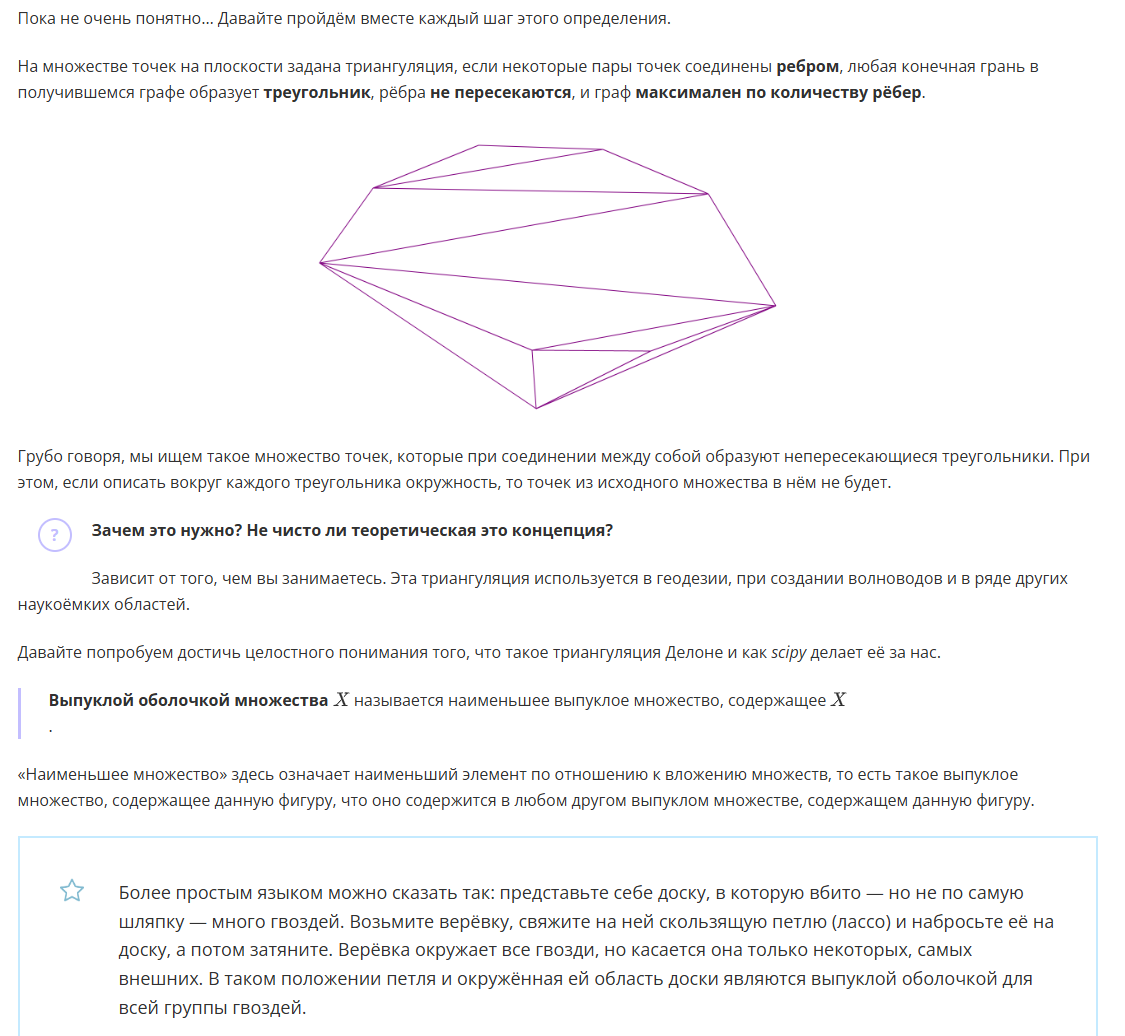

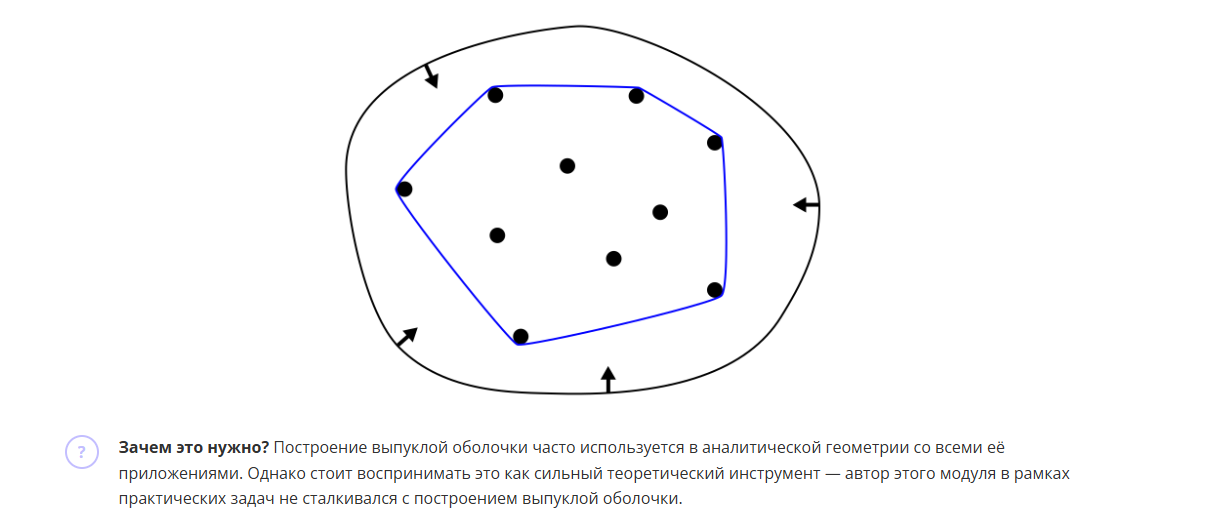

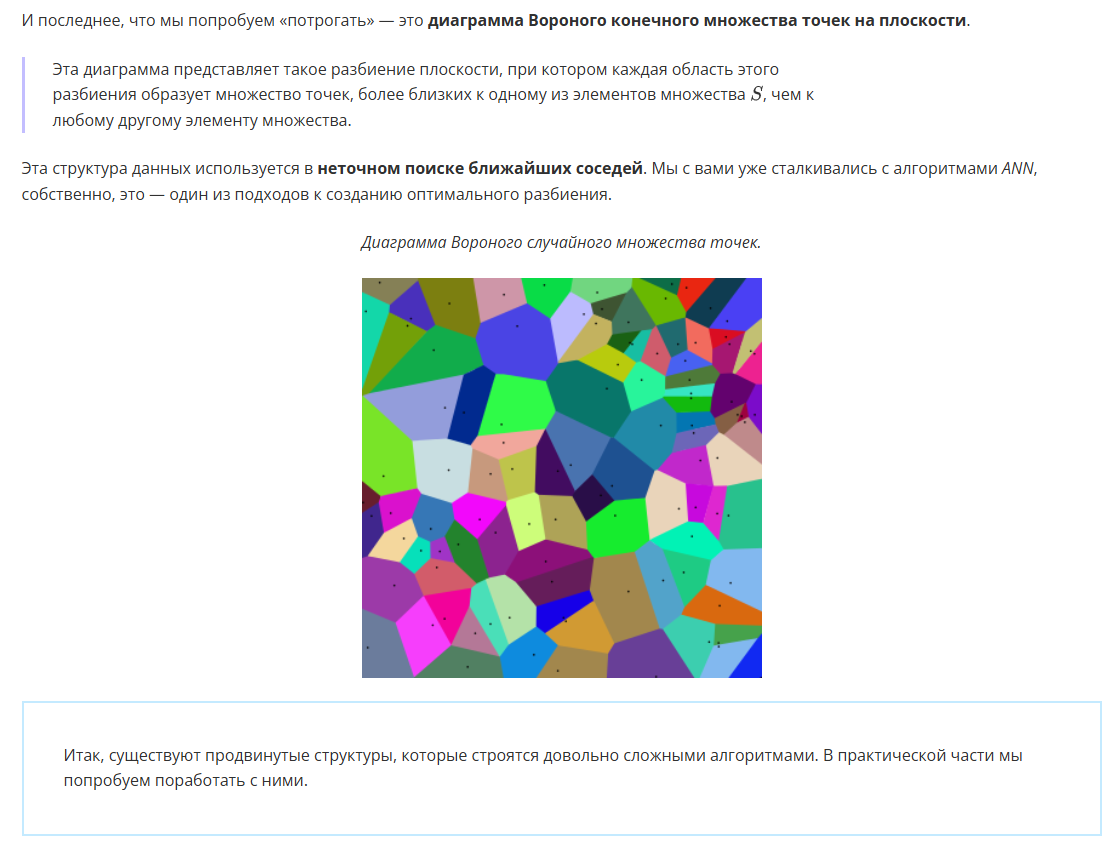

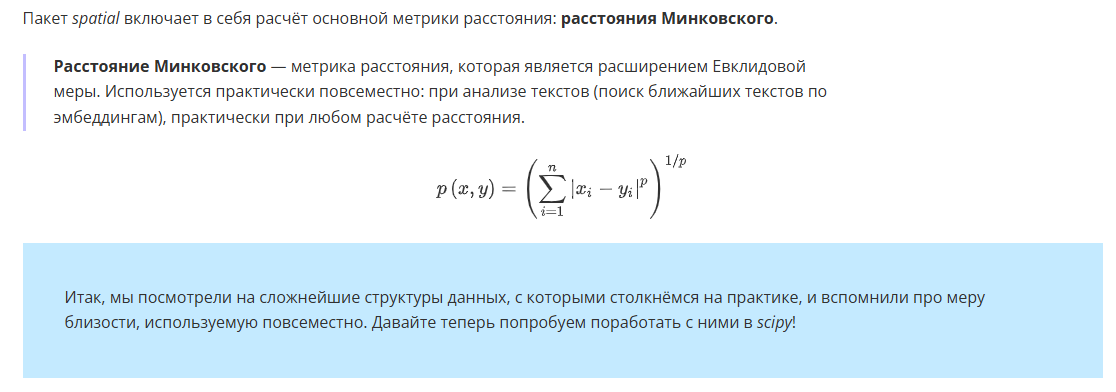

# 5. Матрицы расстояний. Практика

Поработаем немного на практике с тем, что мы изучили в теории. 

Мы посмотрели, что концепции сами по себе довольно сложные, но scipy позволяет нам их упростить! Достаточно сделать нужный импорт.

### Триангуляция Делоне

Импортируем необходимый класс:

In [13]:
from scipy.spatial import Delaunay

Возьмём какое-то множество точек, из которых хотим посчитать триангуляцию Делоне.

In [14]:
points = np.array([[0, 0], [0, 1.1], [1, 0], [1, 1]])

from scipy import optimize

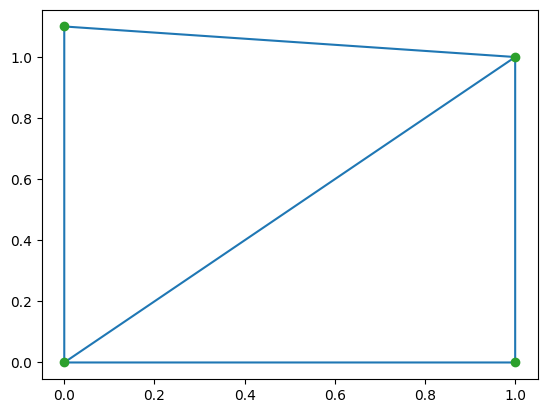

In [15]:
tri = Delaunay(points)

import matplotlib.pyplot as plt
plt.triplot(points[:,0], points[:,1], tri.simplices)
plt.plot(points[:,0], points[:,1], 'o')
plt.show()

Итак, всё готово: scipy нашёл такие точки, при соединении которых мы получим искомую триангуляцию. Просто, не правда ли?

### Выпуклая оболочка

Давайте посмотрим на построение выпуклой оболочки.

Импортируем необходимые классы:

In [16]:
from scipy.spatial import ConvexHull

Построим оболочку для точек из примера 1:

In [17]:
hull = ConvexHull(points)

Изобразим её:

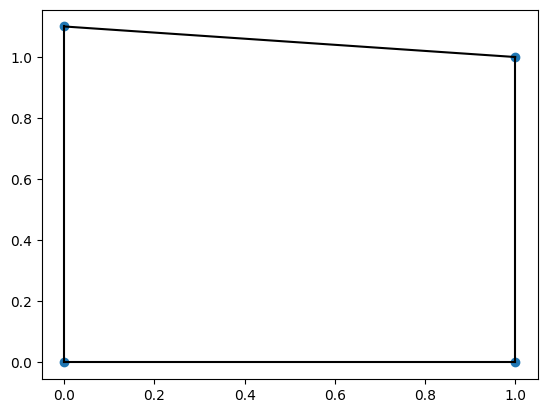

In [18]:
import matplotlib.pyplot as plt
plt.plot(points[:,0], points[:,1], 'o')
for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'k-')

### Диаграммы Вороного

Пришло время построить диаграммы Вороного.

Импортируем необходимые классы и функции:

In [19]:
from scipy.spatial import Voronoi, voronoi_plot_2d

Построим диаграмму и отрисуем её.

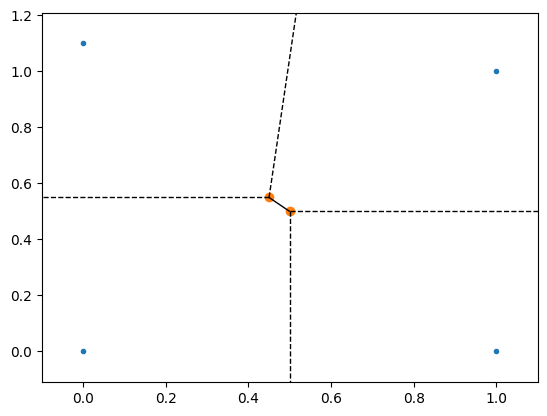

In [20]:
vor = Voronoi(points)
fig = voronoi_plot_2d(vor)
plt.show()

### Матрицы расстояний

Теперь давайте научимся считать матрицы расстояний при помощи scipy. Это осуществляется функцией distance_matrix модуля spatial.

Импортируем функцию:

In [21]:
from scipy.spatial import distance_matrix

Посчитаем пример евклидова расстояния между векторами.

In [22]:
distance_matrix([[0, 1]], [[1, 2]], p=2)

array([[1.41421356]])

Посчитаем расстояние Минковского третьей степени между матрицами.

In [23]:
distance_matrix([[0, 1], [0, 1]], [[1, 2], [0, 1]], p=3)

array([[1.25992105, 0.        ],
       [1.25992105, 0.        ]])

А теперь ваша очередь потренироваться!

### Задание 5.2
 
Выберите картинку, соответствующую триангуляции Делоне следующего набора точек:

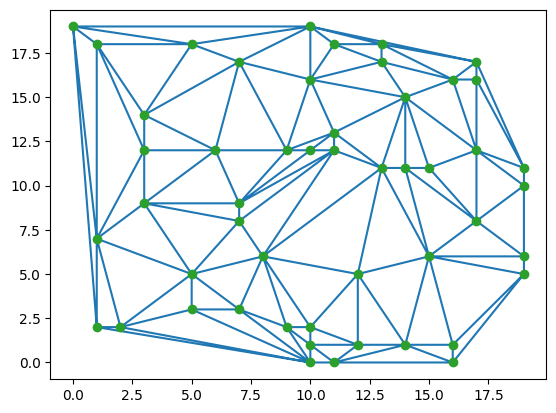

In [28]:
points = [(12, 1), (7, 17), (7, 3), (10, 12), (14, 15), (1, 2), (13, 11), (17, 16), (5, 18),
(10, 16), (9, 12), (3, 14), (12, 5), (19, 6), (13, 17), (17, 17), (1, 7), (1, 18), (19, 11), (14, 11),
(15, 11), (10, 1), (9, 2), (17, 12), (11, 18), (5, 5), (10, 0), (16, 0), (14, 1), (7, 9), (5, 3), (11,
13), (2, 2), (0, 19), (3, 12), (7, 8), (11, 12), (3, 9), (10, 2), (16, 1), (13, 18), (19, 5), (15, 6),
(17, 8), (8, 6), (10, 19), (19, 10), (16, 16), (11, 0), (6, 12)]

points = np.asarray(points)
tri = Delaunay(points)

plt.triplot(points[:, 0], points[:, 1], tri.simplices)
plt.plot(points[:, 0], points[:, 1], 'o')
plt.show()

### Задание 5.3
 
Как будет выглядеть выпуклая оболочка поверх точек из предыдущего задания?

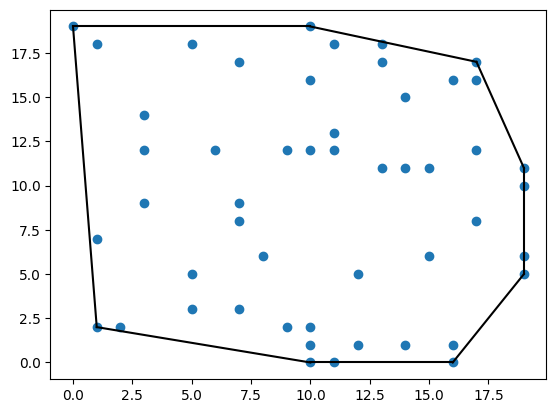

In [29]:
hull = ConvexHull(points)

plt.plot(points[:,0], points[:,1], 'o')
for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'k-')

### Задание 5.4
 
Как будет выглядеть диаграмма Вороного по точкам из задания 5.2 (с точностью до цветов)?

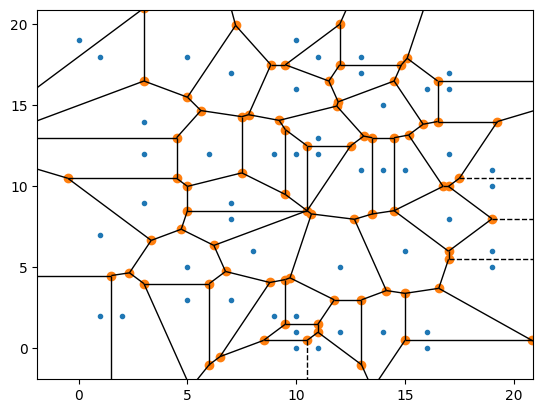

In [30]:
from scipy.spatial import Voronoi, voronoi_plot_2d

vor = Voronoi(points)
fig = voronoi_plot_2d(vor)
plt.show()

### Задание 5.5
 
Посчитайте матрицу расстояний Минковского пятой степени между

points_1 = [(0, 0), (28, 13), (21, 24), (5, 17), (13, 8)]

и

points_2 = [(2, 17), (6, 6), (8, 25), (13, 28), (19, 15)]

In [32]:
import numpy as np
from scipy.spatial.distance import cdist

points_1 = np.array([(0, 0), (28, 13), (21, 24), (5, 17), (13, 8)])
points_2 = np.array([(2, 17), (6, 6), (8, 25), (13, 28), (19, 15)])

minkowski_p5 = cdist(points_1, points_2, metric="minkowski", p=5)
print(np.round(minkowski_p5, 6))

[[17.000077  6.89219  25.016755 28.119784 20.044147]
 [26.000448 22.014331 20.301794 17.230475  9.000975]
 [19.025723 19.258148 13.000007  8.049386  9.000975]
 [ 3.       11.000014  8.01183  11.415088 14.000167]
 [11.709113  7.002664 17.007477 20.        7.55313 ]]


# 6. Встроенное решение задач оптимизации

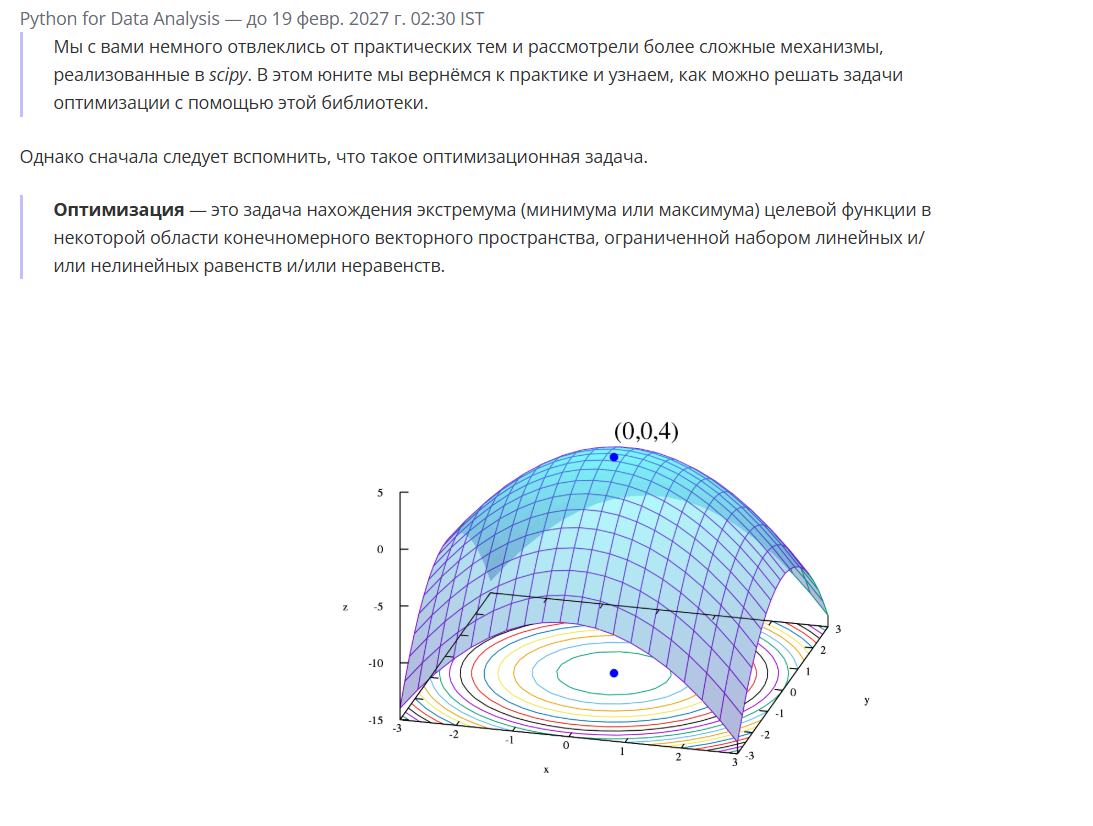

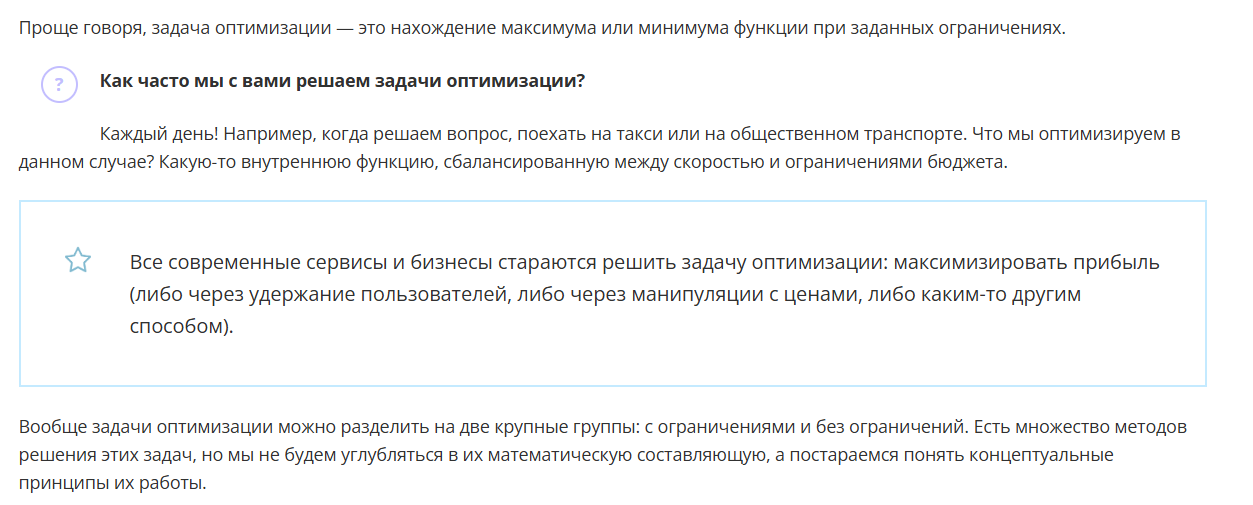

### Оптимизация без ограничений

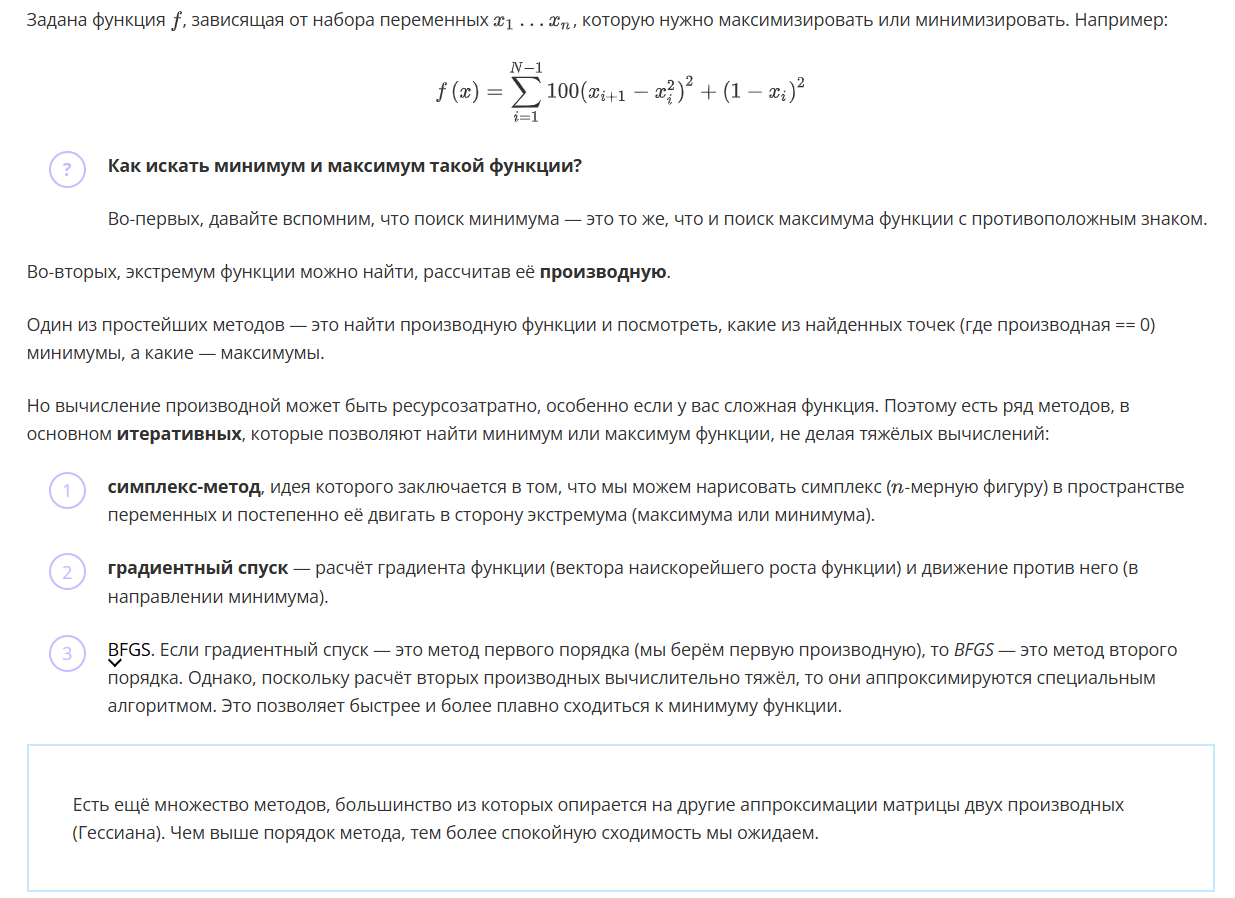

### Оптимизация с ограничениями

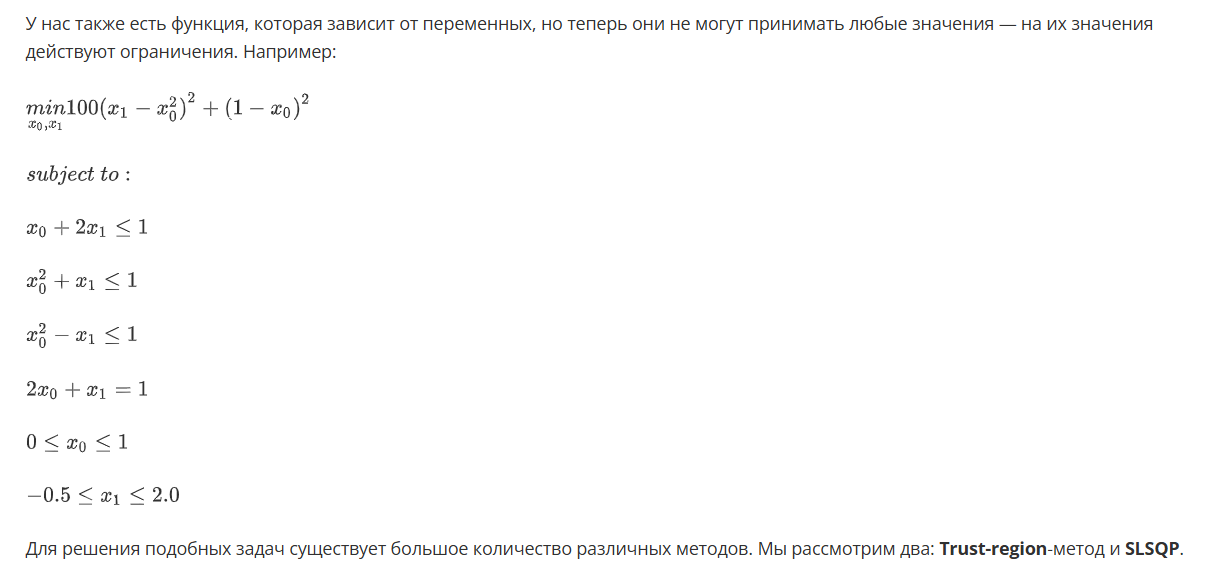

Мы рассмотрим два: Trust-region-метод и SLSQP.

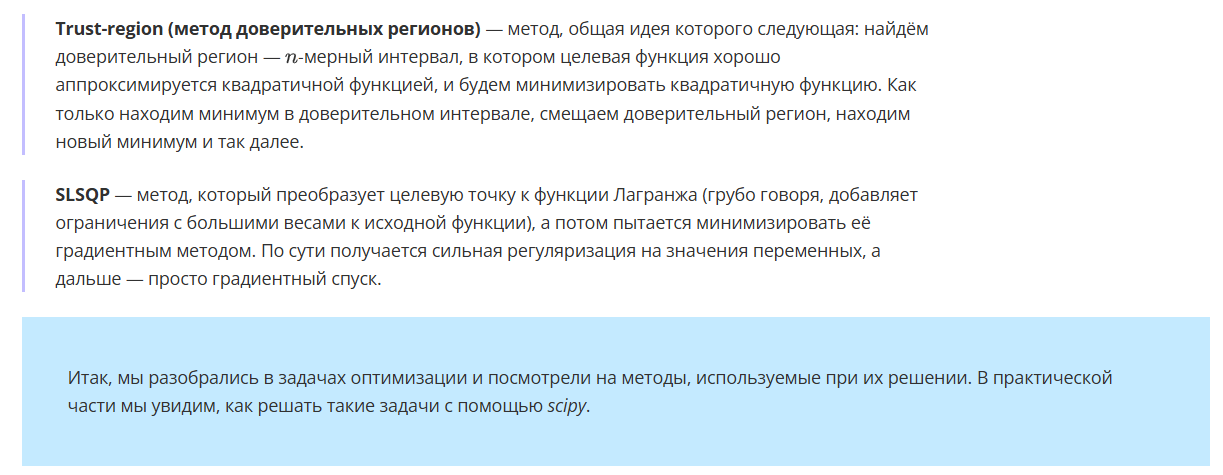

# 7. Встроенное решение задач оптимизации. Практика

Теория может несколько напугать своей сложностью, но давайте посмотрим, как работает пакет scipy.optimize. 

Начнём с оптимизации без ограничений.

### Оптимизация без ограничений

Импортируем необходимые функции и классы:

In [33]:
import numpy as np
from scipy.optimize import minimize

Давайте зададим функцию, которую хотим минимизировать.

In [34]:
def function_to_minimize(x):
    return x[0]**3 + 4 * x[0]**2 + 10 + 30*x[1]**2

Получим результат различными методами. Для этого нужно передать в метод minimize функцию и стартовую точку (поскольку часть алгоритмов итеративная, они могут сойтись к локальному оптимуму, поэтому стартовая точка может повлиять на итоговый результат).

In [35]:
# Симплекс-метод
x0 = np.array([1, 3])
res = minimize(function_to_minimize, x0, method='nelder-mead', options={'xatol': 1e-8, 'disp': True})

Optimization terminated successfully.
         Current function value: 10.000000
         Iterations: 81
         Function evaluations: 155


Мы видим, что минимальное значение функции 10, к нему мы сошлись за 81 итерацию, расчёт значений функции производили 155 раз.

In [36]:
# BFGS
res = minimize(function_to_minimize, x0, method='bfgs', options={'xatol': 1e-8, 'disp': True})


         Current function value: -645910098997.281128
         Iterations: 2
         Function evaluations: 351
         Gradient evaluations: 113


C:\Users\tgorbunov\AppData\Local\Temp\ipykernel_39984\716245101.py:2: OptimizeWarning: Unknown solver options: xatol
  res = minimize(function_to_minimize, x0, method='bfgs', options={'xatol': 1e-8, 'disp': True})
C:\Users\tgorbunov\AppData\Roaming\Python\Python310\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


Видим, что симплекс-метод справился лучше. В переменной res в обоих случаях лежат значения X, при которых достигнуто целевое значение.

Давайте зададим функцию, которую нельзя минимизировать, и посмотрим, что выдадут различные методы.

In [37]:
def linear(x):
    return x[0]
res = minimize(linear, x0, method='nelder-mead', options={'xatol': 1e-8, 'disp': True})
res = minimize(linear, x0, method='bfgs', options={'xatol': 1e-8, 'disp': True})

C:\Users\tgorbunov\AppData\Local\Temp\ipykernel_39984\4014877376.py:3: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  res = minimize(linear, x0, method='nelder-mead', options={'xatol': 1e-8, 'disp': True})
C:\Users\tgorbunov\AppData\Local\Temp\ipykernel_39984\4014877376.py:4: OptimizeWarning: Unknown solver options: xatol
  res = minimize(linear, x0, method='bfgs', options={'xatol': 1e-8, 'disp': True})
C:\Users\tgorbunov\AppData\Roaming\Python\Python310\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Divide-by-zero encountered: rhok assumed large
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
C:\Users\tgorbunov\AppData\Roaming\Python\Python310\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Divide-by-zero encountered: rhok assumed large
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
C:\Users\tgorbunov\AppData\Roaming\Python\Python310\site-packages\scipy\optimize\_minimize.py:733: OptimizeWar

         Current function value: -339211811099097138715818266642692985742503535472172481368912884097961292874812054461869822029578419403423632352571912698933392921568124677863601437790961664.000000
         Iterations: 47
         Function evaluations: 10555
         Gradient evaluations: 3518


C:\Users\tgorbunov\AppData\Roaming\Python\Python310\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Divide-by-zero encountered: rhok assumed large
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
C:\Users\tgorbunov\AppData\Roaming\Python\Python310\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Divide-by-zero encountered: rhok assumed large
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
C:\Users\tgorbunov\AppData\Roaming\Python\Python310\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Divide-by-zero encountered: rhok assumed large
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
C:\Users\tgorbunov\AppData\Roaming\Python\Python310\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Divide-by-zero encountered: rhok assumed large
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
C:\Users\tgorbunov\AppData\Roaming\Python\Python310\site-packages\scipy\optimize\_minimize.p

Текст ошибки говорит о том, что мы не смогли прийти к решению в обоих случаях.

Итак, мы убедились в том, что сложнейшие методы оптимизации укладываются в вызов нескольких функций. 

### Оптимизация с ограничениями

Так ли всё просто с оптимизацией с ограничениями? 

К сожалению, нет. Для нелинейных ограничений необходимо определить **якобиан** (матрицу первых производных) и **гессиан** (матрицу вторых производных) для заданной функции. Но, поскольку мы о них не говорили, давайте посмотрим на простейшие линейные ограничения.

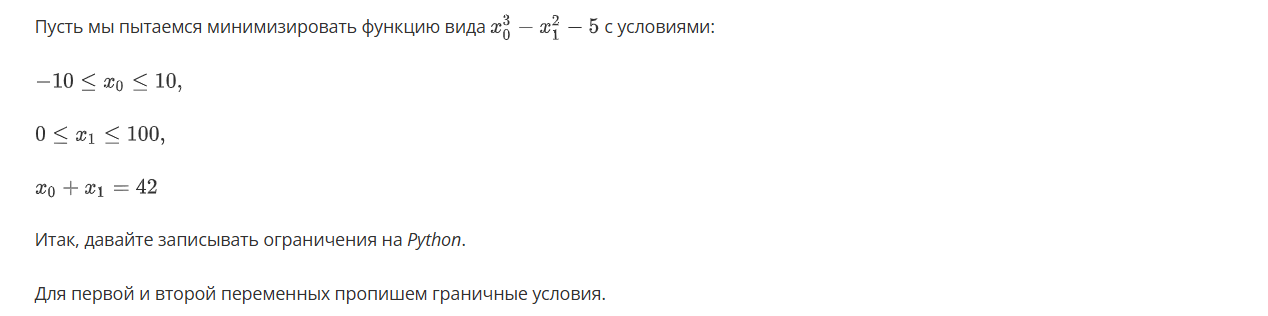

In [38]:
from scipy.optimize import Bounds
bounds = Bounds ([-10, 0], [10, 100.0])

Сформулируем вид линейного ограничения.

In [39]:
import numpy as np
from scipy.optimize import LinearConstraint
linear_constraint = LinearConstraint ([[1, 1]], [42], [42])

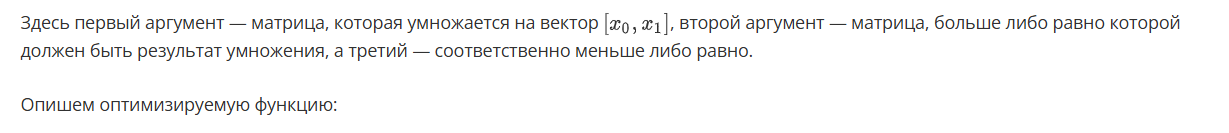

In [40]:
def func(x):
    return x[0]**3 - 5*x[1]**2 -5

Запустим процесс оптимизации:

In [41]:
x0 = np.array([0.5, 0])
res = minimize(func, x0, method='trust-constr', constraints=[linear_constraint],
        options={'verbose': 1}, bounds=bounds)

`gtol` termination condition is satisfied.
Number of iterations: 10, function evaluations: 27, CG iterations: 8, optimality: 9.44e-12, constraint violation: 0.00e+00, execution time: 0.041 s.


Мы видим, что метод доверительных регионов сошёлся. Посмотрим на SLSQP:

In [42]:
res = minimize(func, x0, method='SLSQP', constraints=[linear_constraint],
            bounds=bounds)

Метод тоже сошёлся.

Мы посмотрели на практике, как решаются оптимизационные задачи при помощи библиотеки SciPy. Давайте теперь потренируемся самостоятельно!

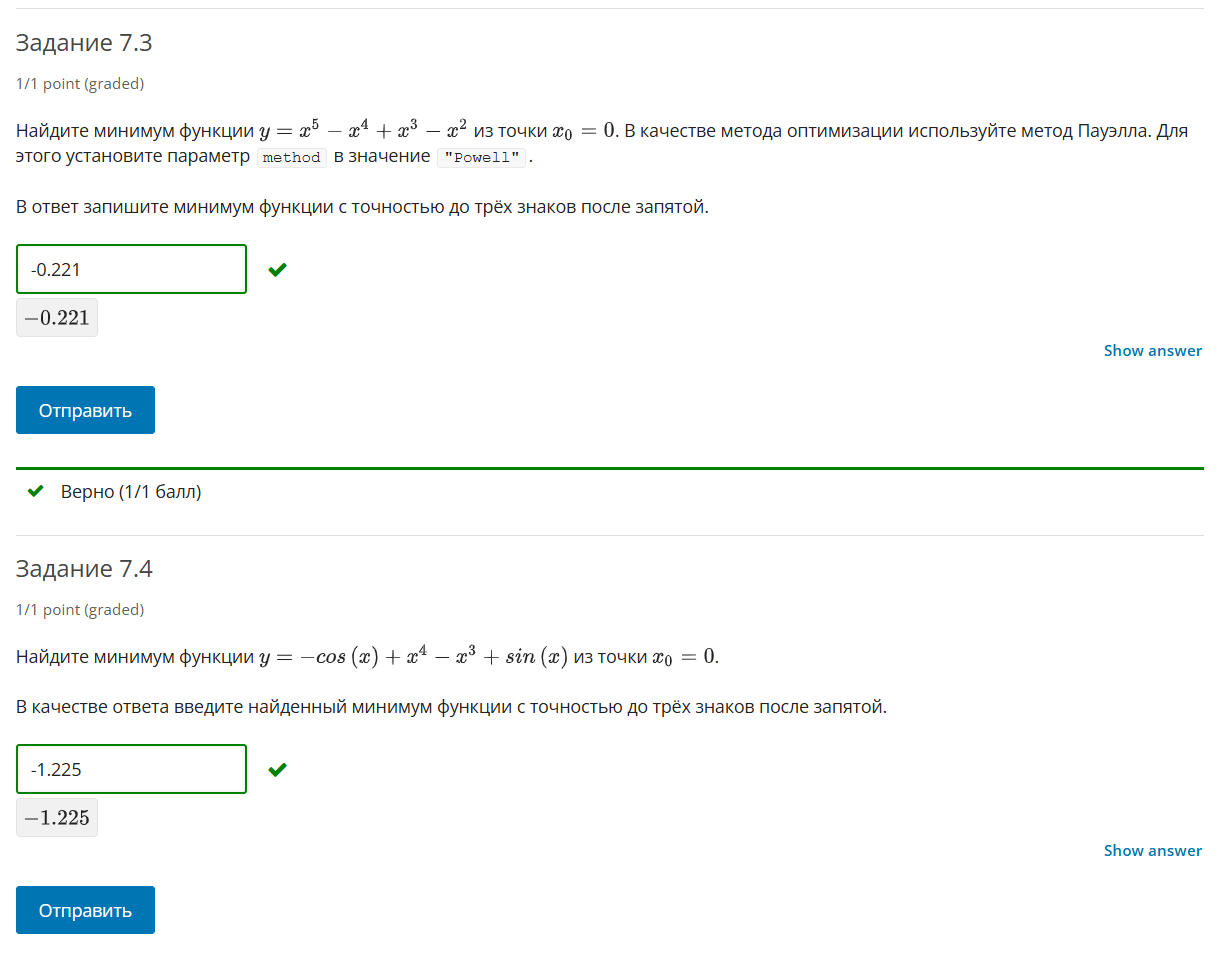

In [50]:
def function_to_minimize(x):
    return x**5 - x**4 + x**3 - x**2

# Симплекс-метод
x0 = np.array([0])
res = minimize(
    function_to_minimize, 
    x0, 
    method='Powell', 
    options={'xatol': 1e-8, 'disp': True}
)

Optimization terminated successfully.
         Current function value: -0.220559
         Iterations: 2
         Function evaluations: 25


C:\Users\tgorbunov\AppData\Local\Temp\ipykernel_39984\3857304248.py:6: OptimizeWarning: Unknown solver options: xatol
  res = minimize(


In [51]:
def function_to_minimize(x):
    return -np.cos(x) + x**4 - x**3 + np.sin(x)

# Симплекс-метод
x0 = np.array([0])
res = minimize(
    function_to_minimize, 
    x0, 
    method='SLSQP', 
    options={'xatol': 1e-8, 'disp': True}
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.2247254829399852
            Iterations: 5
            Function evaluations: 12
            Gradient evaluations: 5


C:\Users\tgorbunov\AppData\Local\Temp\ipykernel_39984\2547628389.py:6: OptimizeWarning: Unknown solver options: xatol
  res = minimize(


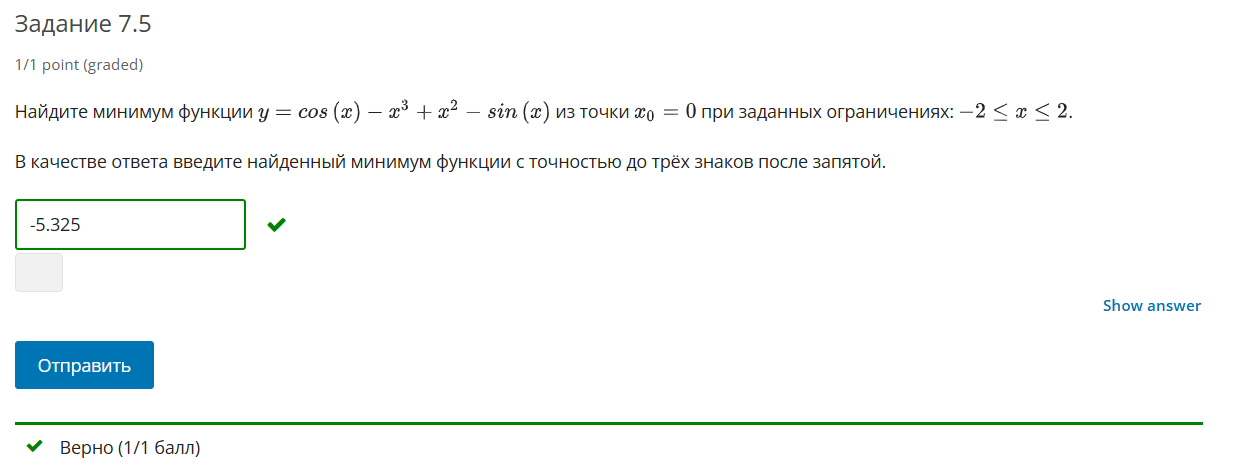

In [ ]:
def function_to_minimize(x):
    return np.cos(x) - x**3 + x**2 - np.sin(x)

bounds = Bounds ([-2], [2])

# Симплекс-метод
x0 = np.array([0])
res = minimize(
    function_to_minimize, 
    x0, 
    method='Powell', 
    bounds=bounds,
    options={'xatol': 1e-8, 'disp': True}
)

# 8. Интерполяция

Итак, мы на финишной прямой! Последняя тема этого модуля — интерполяция. 

Библиотека SciPy представляет собой довольно мощный инструмент для работы с задачами интерполяции, но давайте сперва вспомним, что такое интерполяция. 

**Интерполяция** — это нахождение промежуточных точек какой-то функции. 

Представьте себе линию, из которой выкинули отрезок. Задача интерполяции — заполнить этот отрезок.

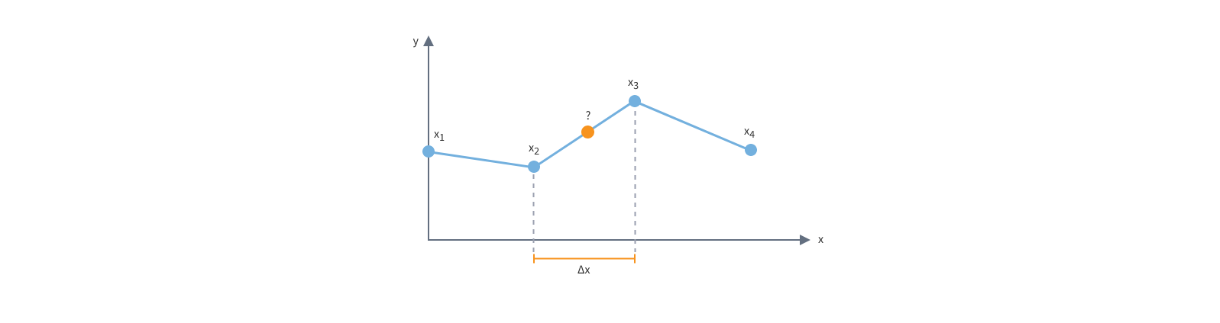

Интерполяцию можно совершать несколькими методами. Давайте их рассмотрим.

### Метод ближайшего соседа

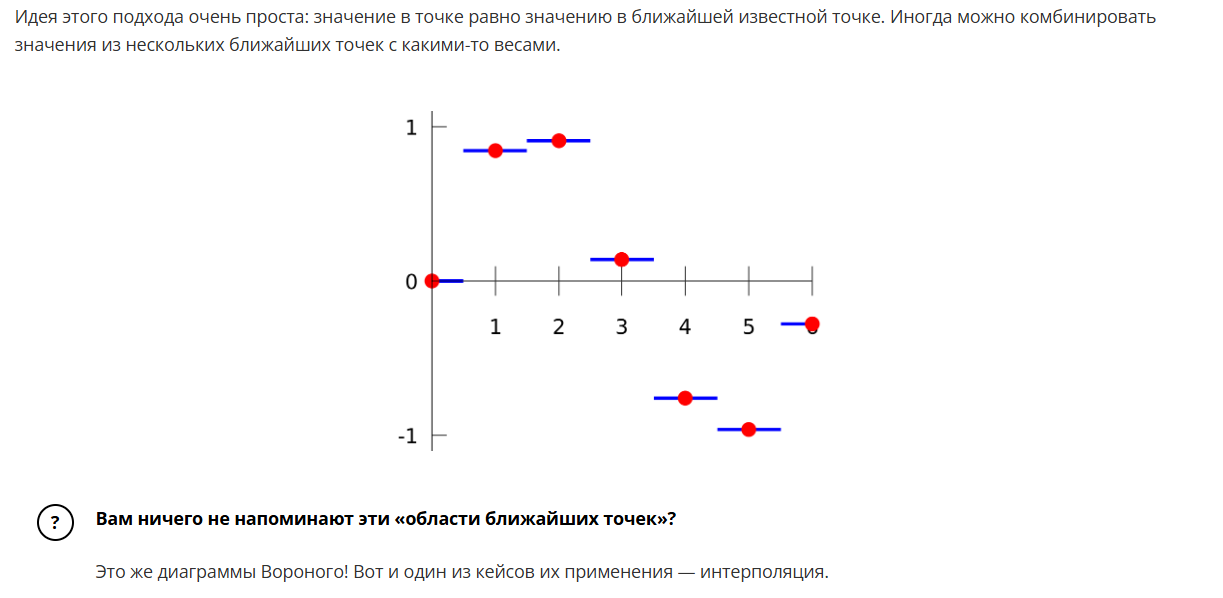

### Интерполяция многочленами

Идея метода заключается в приближении исходной функции каким-то многочленом в окрестности восстанавливаемой точки. 

Существует множество подходов, но мы посмотрим на простейший из них — **линейную интерполяцию**. Из названия понятно, что мы пытаемся аппроксимировать исходную функцию линейно.

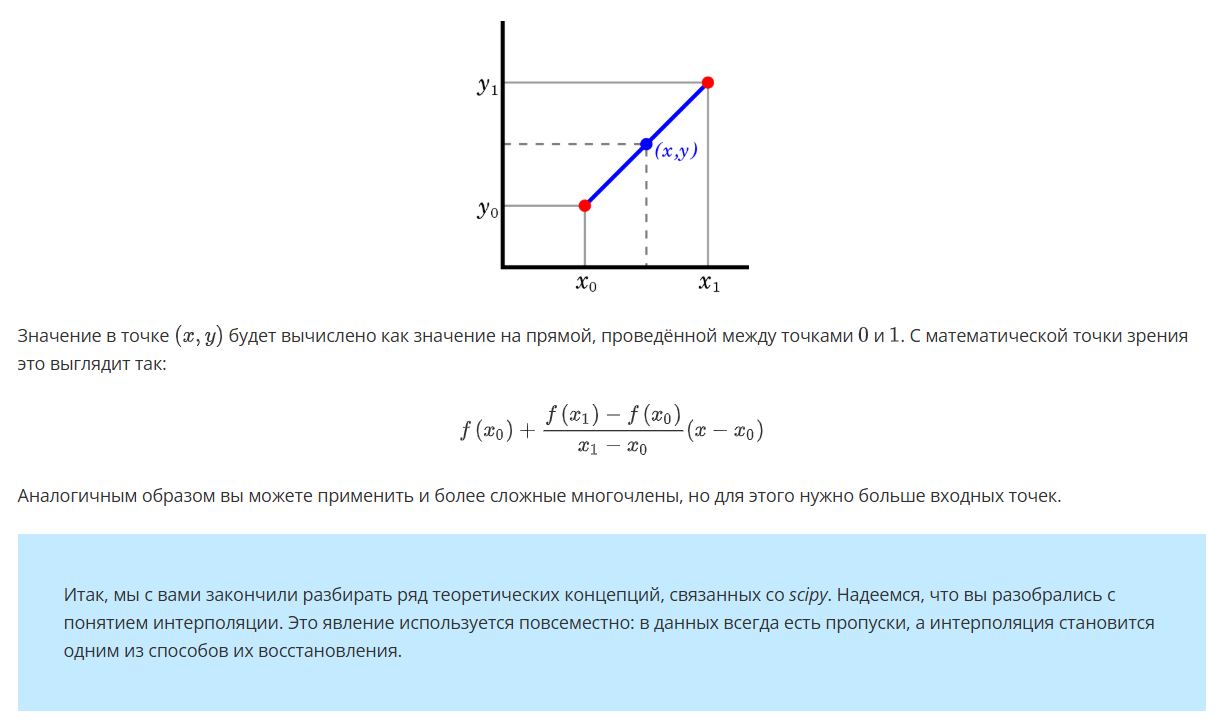

# 9. Интерполяция. Практика

Интерполяция в scipy делается методом interp1d. Давайте его импортируем и попробуем восстановить какую-нибудь функцию.

Импортируем необходимые методы:

In [43]:
from scipy.interpolate import interp1d

Сгенерируем точки, соответствующие функции косинуса.



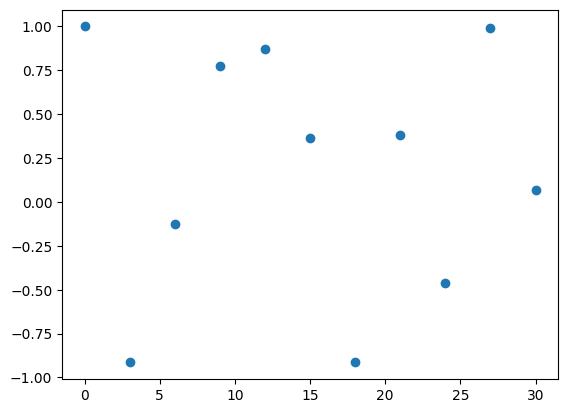

In [44]:
x = np.linspace(0, 30, num=11, endpoint=True)
y = np.cos(-x**2)
import matplotlib.pyplot as plt
plt.plot(x, y, 'o')

Попробуем построить интерполяцию линейную, квадратичную и кубическую.

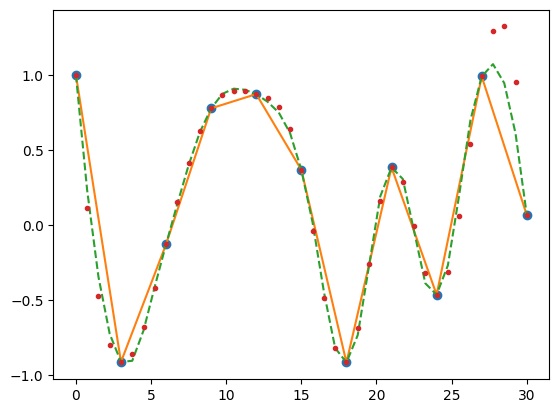

In [45]:
xnew = np.linspace(0, 30, num=41, endpoint=True)
f = interp1d(x, y)
f2 = interp1d(x, y, kind='quadratic')
f3 = interp1d(x, y, kind='cubic')
plt.plot(x, y, 'o', xnew, f(xnew), '-', xnew, f2(xnew), '--', xnew, f3(xnew), '.')
plt.show()

Итак, мы видим, что чем выше степень многочлена, тем плавнее аппроксимация. Однако важно помнить, что если степень слишком высокая, вы получите эффект, похожий на **переобучение** — переподгонку под данные.

### Задание 9.1

Запишите значение, которое будет получено в точке X = 5.5 линейной интерполяцией по множеству:

In [ ]:
[(0.0, -0.0), (1.0, -1.5574077246549023), (2.0, -1.1578212823495777), 
(3.0, 0.45231565944180985), (4.0, -0.3006322420239034), (5.0, 0.13352640702153587),
(6.0, -7.750470905699148), (7.0, 3.172908552159191), (8.0, -2.3478603091954366), 
(9.0, 0.8109944158318942), (10.0, 0.5872139151569291)]

In [47]:
import numpy as np
from scipy.interpolate import interp1d

points = [
    (0.0, -0.0), (1.0, -1.5574077246549023), (2.0, -1.1578212823495777),
    (3.0, 0.45231565944180985), (4.0, -0.3006322420239034), (5.0, 0.13352640702153587),
    (6.0, -7.750470905699148), (7.0, 3.172908552159191), (8.0, -2.3478603091954366),
    (9.0, 0.8109944158318942), (10.0, 0.5872139151569291)
]

x = np.array([p[0] for p in points])
y = np.array([p[1] for p in points])

f = interp1d(x, y, kind="linear")
print(float(f(5.5)))

-3.808472249338806


###Задание 9.2
 
Какое значение будет получено в точке X=4.5 квадратичной интерполяцией по множеству из предыдущего задания?

In [49]:
import numpy as np
from scipy.interpolate import interp1d

points = [
    (0.0, -0.0), (1.0, -1.5574077246549023), (2.0, -1.1578212823495777),
    (3.0, 0.45231565944180985), (4.0, -0.3006322420239034), (5.0, 0.13352640702153587),
    (6.0, -7.750470905699148), (7.0, 3.172908552159191), (8.0, -2.3478603091954366),
    (9.0, 0.8109944158318942), (10.0, 0.5872139151569291)
]

x = np.array([p[0] for p in points])
y = np.array([p[1] for p in points])

f_quadratic = interp1d(x, y, kind="quadratic")
print(float(f_quadratic(4.5)))

0.6820171741344402


# 10. Итоги

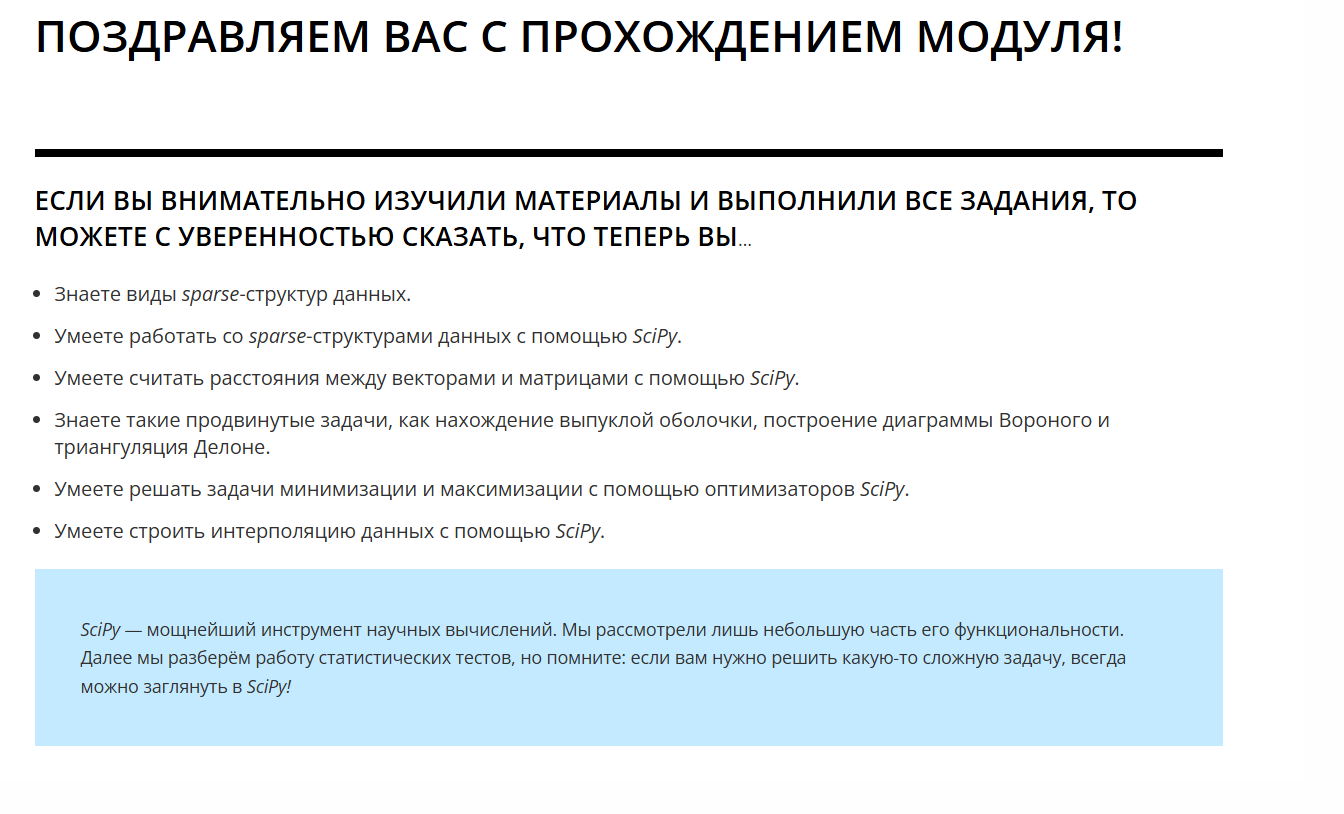